In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
# Generation data
gen1 = pd.read_csv('Plant_1_Generation_Data.csv')
gen2 = pd.read_csv('Plant_2_Generation_Data.csv')

# Weather/sensor data
sensor1 = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
sensor2 = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

In [56]:
gen1.head()         # first 5 rows
gen1.info()         # column names, data types, null counts
gen1.describe()     # basic statsgen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'])
sensor1['DATE_TIME'] = pd.to_datetime(sensor1['DATE_TIME'])

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 3.7 MB


In [57]:
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'])
sensor1['DATE_TIME'] = pd.to_datetime(sensor1['DATE_TIME'])

/var/folders/lq/zrv3gxl950xdcblsynmp67lr0000gp/T/ipykernel_91645/3830399796.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'])


In [58]:
plant1 = pd.merge(gen1, sensor1, on='DATE_TIME', how='inner')
plant1.head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [59]:
# Check for missing values
plant1.isnull().sum()

# Drop rows with nulls (or fill them — your call)
plant1 = plant1.dropna()

# Check for duplicates
plant1.duplicated().sum()
plant1 = plant1.drop_duplicates()

In [60]:
plant2 = pd.merge(gen2, sensor2, on='DATE_TIME', how='inner')

# Add a label so you know which plant is which
plant1['PLANT'] = 'Plant 1'
plant2['PLANT'] = 'Plant 2'

# Stack them into one dataframe
df = pd.concat([plant1, plant2], ignore_index=True)

In [61]:
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

In [62]:
# Key column names in DataFrame 

#DATE_TIME — timestamp of the reading
#DC_POWER — power output before the inverter
#AC_POWER — power output after the inverter (what actually goes to the grid)
#DAILY_YIELD — energy generated so far that day
#AMBIENT_TEMPERATURE — air temp
#MODULE_TEMPERATURE — panel surface temp
#IRRADIATION — sunlight hitting the panels

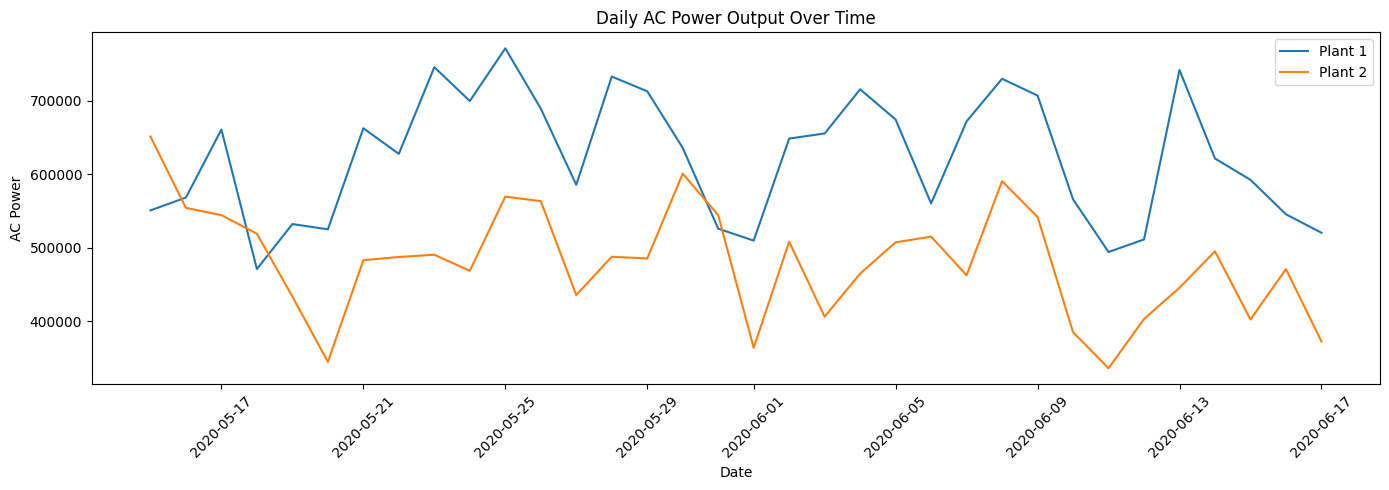

In [63]:
# Group by date and sum up daily AC power output
daily_output = df.groupby([df['DATE_TIME'].dt.date, 'PLANT'])['AC_POWER'].sum().reset_index()
daily_output.columns = ['Date', 'Plant', 'Total_AC_Power']

# Plot it
plt.figure(figsize=(14, 5))
for plant in daily_output['Plant'].unique():
    subset = daily_output[daily_output['Plant'] == plant]
    plt.plot(subset['Date'], subset['Total_AC_Power'], label=plant)

plt.title('Daily AC Power Output Over Time')
plt.xlabel('Date')
plt.ylabel('AC Power')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

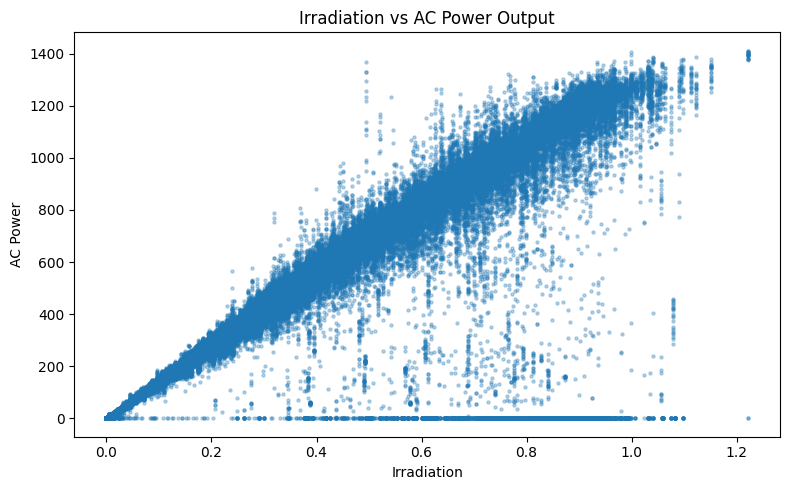

In [64]:
# Irradiation vs Power Output
plt.figure(figsize=(8, 5))
plt.scatter(df['IRRADIATION'], df['AC_POWER'], alpha=0.3, s=5)
plt.title('Irradiation vs AC Power Output')
plt.xlabel('Irradiation')
plt.ylabel('AC Power')
plt.tight_layout()
plt.show()

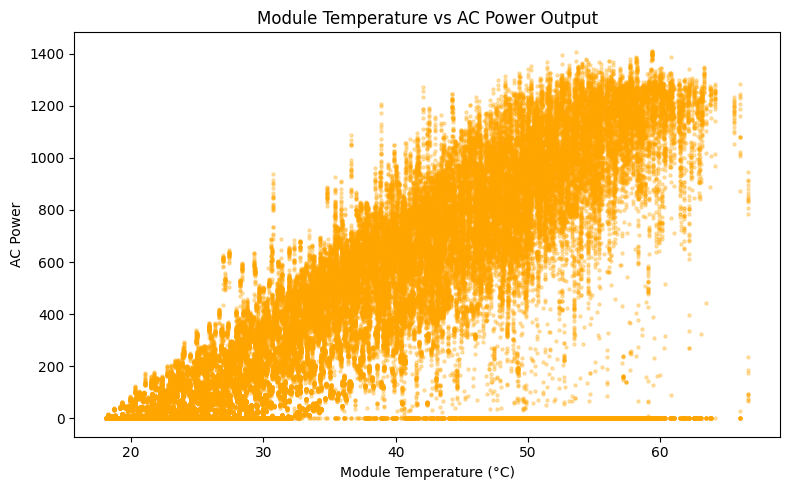

In [65]:
# Temperature effect on performance
plt.figure(figsize=(8, 5))
plt.scatter(df['MODULE_TEMPERATURE'], df['AC_POWER'], alpha=0.3, s=5, color='orange')
plt.title('Module Temperature vs AC Power Output')
plt.xlabel('Module Temperature (°C)')
plt.ylabel('AC Power')
plt.tight_layout()
plt.show()

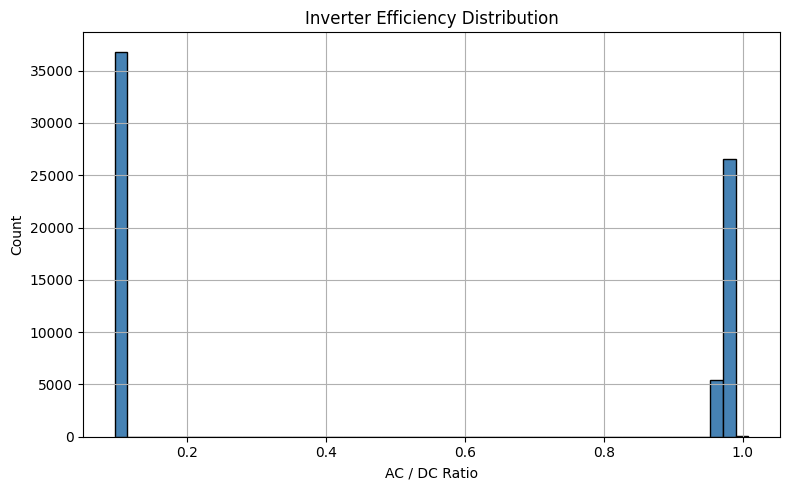

In [66]:
# DC to AC conversion efficiency (inverter health)
df['INVERTER_EFFICIENCY'] = df['AC_POWER'] / df['DC_POWER'].replace(0, np.nan)

plt.figure(figsize=(8, 5))
df['INVERTER_EFFICIENCY'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Inverter Efficiency Distribution')
plt.xlabel('AC / DC Ratio')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [67]:
# Anomaly Detection 
# Calculate expected power based on irradiation using rolling average
df = df.sort_values('DATE_TIME')
df['EXPECTED_POWER'] = df['IRRADIATION'] * df['AC_POWER'].mean() / df['IRRADIATION'].mean()

# Flag rows where actual output is much lower than expected
df['ANOMALY'] = df['AC_POWER'] < (df['EXPECTED_POWER'] * 0.7)  # 30% below expected

print(f"Total anomalies flagged: {df['ANOMALY'].sum()}")
print(f"That's {df['ANOMALY'].mean()*100:.1f}% of all readings")

Total anomalies flagged: 10200
That's 7.5% of all readings


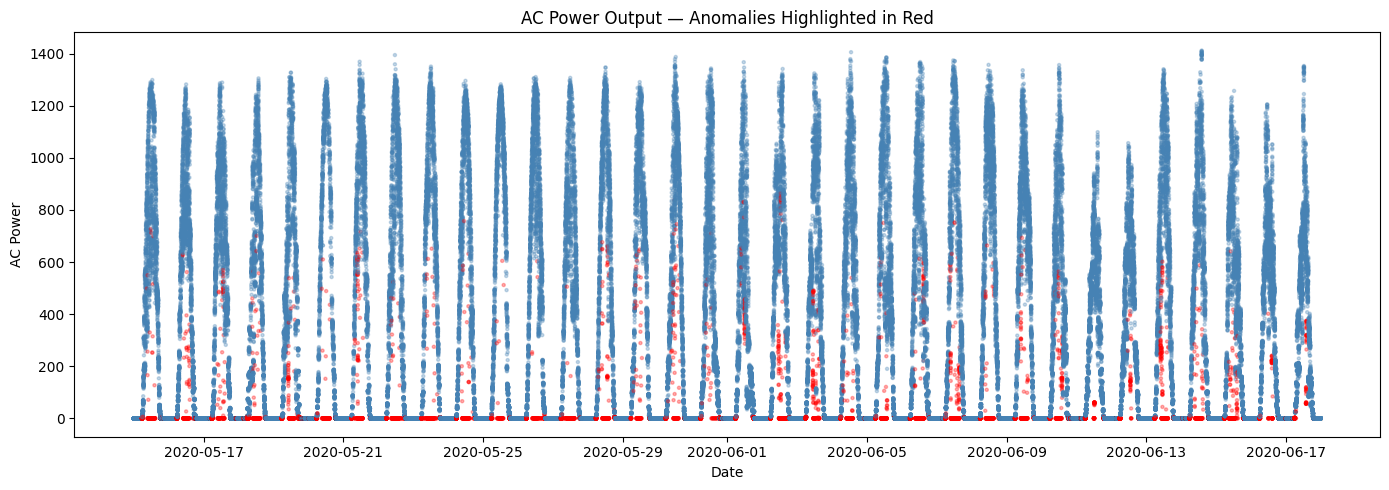

In [68]:
# Visualize Anomalies 

plt.figure(figsize=(14, 5))
plt.scatter(df['DATE_TIME'], df['AC_POWER'], c=df['ANOMALY'].map({True: 'red', False: 'steelblue'}), alpha=0.3, s=5)
plt.title('AC Power Output — Anomalies Highlighted in Red')
plt.xlabel('Date')
plt.ylabel('AC Power')
plt.tight_layout()
plt.show()